In [38]:
import scanpy as sc
import treedata as td
import pycea as py
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Import utility functions made by Katie
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')

from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom

In [2]:
dark_blue = '#332288'
blue = '#6699CC'
light_blue = '#88CCEE'
teal = '#44AA99'
green = '#117733'
yellow = '#999933'
light_yellow = "#DDCC77"
maroon = '#661100'
light_pink = '#CC6677'
medium_pink = "#AA4466"
pink = '#882255'
dark_pink = '#AA4499'



In [3]:
palette = [
    "#1D9E75",
    "#534AB7",
    "#D85A30",
    "#378ADD",
    "#D4537E",
    "#639922",
    "#BA7517",
    "#E24B4A",
    "#0F6E56",
    "#3C3489",
    "#993C1D",
    "#185FA5",
    "#993556",
    "#3B6D11",
    "#854F0B",
    "#A32D2D",
    "#5DCAA5",
    "#7F77DD",
    "#F09575",
    "#85B7EB",
    "#ED93B1",
    "#97C459",
    "#EF9F27",
    "#F09595",
    "#9FE1CB",
    "#AFA9EC",
    "#F5C4B3",
    "#B5D4F4",
    "#F4C0D1",
    "#C0DD97",
    "#FAC775",
    "#F7C1C1",
    "#04342C",
    "#26215C",
    "#4A1B0C",
    "#042C53",
    "#4B1528",
    "#173404",
    "#412402",
    "#501313",
    "#088268",
    "#443F9E",
    "#C04E24",
    "#2771C0",
    "#BF4570",
    "#4D7F18",
    "#A06512",
    "#C73F3E",
    "#1D5E82",
    "#7A2848",
    "#7B3F9E",
    "#2AABBA",
    "#E8860A",
    "#5C8526",
    "#C4396B",
    "#1A6B8A",
    "#9E5B1D",
    "#3D2D8A",
    "#B5991A",
    "#6B1A3A"
]

In [4]:
output_path_plot = "/project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/"

#### Loading Data

In [5]:
tdatas = []

for file in Path("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Processed_data/").glob("*.h5td"):
    tdatas.append(td.read_h5td(file) )

In [40]:
tdatas[0].obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree,leiden_0.25,leiden_0.5,leiden_1.0,leiden_2.0
E8.5-R1-T2-AGCCTGACATAAGCTA-1,Midbrain,E8.5-R1-T2,E8.5-R1,E8.5,donor,38226.0,48.0,0.939394,0.424242,E8.5-R1-C1,G2/M,Midbrain,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,0,0,0
E8.5-R1-T2-GCAGCCATCTGTAAGT-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,21301.0,6.0,0.878788,0.397849,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,2,4,10
E8.5-R1-T2-TGATCCCCATGGTTAA-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,23958.0,8.0,0.969697,0.421569,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,0,1,2
E8.5-R1-T1-CGTACAGCAACGTGCA-1,Telencephalon (dorsal),E8.5-R1-T1,E8.5-R1,E8.5,donor,48821.0,14.0,0.969697,0.431373,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,0,0,0,4
E8.5-R1-T2-ACGCGGTCAACCAACG-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,31433.0,17.0,0.939394,0.444444,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,4,2,5,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.5-R2-T3-TGTGTACGTTGGCATT-1,Foregut,E8.5-R2-T3,E8.5-R2,E8.5,host,6193.0,4.0,NaN,NaN,NaN,G2/M,Foregut,Endoderm,Endoderm,NaN,9,7,11,43
E8.5-R2-T3-TGTGTTAGTGAGACCG-1,Surface ectoderm (anterior),E8.5-R2-T3,E8.5-R2,E8.5,host,21767.0,0.0,NaN,NaN,NaN,G2/M,Surface ectoderm,Ectoderm,Surface ectoderm,NaN,9,7,12,16
E8.5-R2-T3-TGTGTTGAGCTACGGT-1,Midgut,E8.5-R2-T3,E8.5-R2,E8.5,host,31225.0,1.0,NaN,NaN,NaN,G2/M,Midgut,Endoderm,Endoderm,NaN,9,8,11,55
E8.5-R2-T3-TGTGTTGAGGATCATT-1,Hindbrain (r2-r4),E8.5-R2-T3,E8.5-R2,E8.5,donor,6799.0,6.0,0.303030,NaN,NaN,G2/M,Hindbrain (r2-r4),Ectoderm,Neural ectoderm,NaN,0,10,1,11


In [ ]:
# Color by clones in each time point
for tdata in tdatas:
    tdata.X = tdata.layers['Norm_count']
    day = tdata.obs['stage'][0].replace(".","_")
    plot_UMAP_custom(adata=tdata,
        umap_coords_obsm="X_umap",
        color_by="clone",
        palette = "tab20",
        fig_title="All clones per time point UMAP",
        output_path_plot=output_path_plot+'clone_per_rep_umap/', 
        output_fname=str(day)+"_clonal_rep_Umap.png"
)

/scratch/local/jobs/51345171/ipykernel_1804729/849726970.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  day = tdata.obs['stage'][0].replace(".","_")
/scratch/local/jobs/51345171/ipykernel_1804729/849726970.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  day = tdata.obs['stage'][0].replace(".","_")
/scratch/local/jobs/51345171/ipykernel_1804729/849726970.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  day = tdata.obs['st

In [31]:
# Color by embryo in each time point
for tdata in tdatas:
    tdata.X = tdata.layers['Norm_count']
    day = tdata.obs['stage'].iloc[0].replace(".","_")
    plot_UMAP_custom(adata=tdata,
        umap_coords_obsm="X_umap",
        color_by="embryo",
        palette = "tab10",
        fig_title="All embryo per time point UMAP",
        output_path_plot=output_path_plot+'Harmony_integrated_umap', 
        output_fname=str(day)+"embryo_umap.png"
)

In [38]:
# Colored by cell_type annotation
for tdata in tdatas:
    tdata.X = tdata.layers['Norm_count']
    day = tdata.obs['stage'].iloc[0].replace(".","_")
    plot_UMAP_custom(adata=tdata,
        umap_coords_obsm="X_umap",
        color_by="cell_type",
        palette = palette,
        fig_title="Cell_type annotation by Colgan UMAP",
        output_path_plot=output_path_plot+'umaps/cell_type_Colgan_umap', 
        output_fname=str(day)+"cell_type_umap.png"
)

In [54]:
adata = tdatas[1]

In [55]:
adata

TreeData object with n_obs × n_vars = 21942 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'leiden_0.25', 'leiden_0.25_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'leiden_names', 'log1p', 'neighbors', 'pca', 'umap', 'clone_colors', 'embryo_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters'
    varm: 'PCs'
    layers: 'Norm_count', 'Raw_count'
    obsp: 'connectivities', 'distances'
    obst: 'E8.0-R3-C2', 'E8.0-R2-C2', 'E8.0-R1-C2', 'E8.0-R1-C3', 'E8.0-R2-C1', 'E8.0-R3-C5', 'E8.0-R3-C1', 'E8.0-R1-C1', 'E8.0-R3-C6', 'E8.0-R3-C4', 'E8.0-R3-C3'

<Axes: >

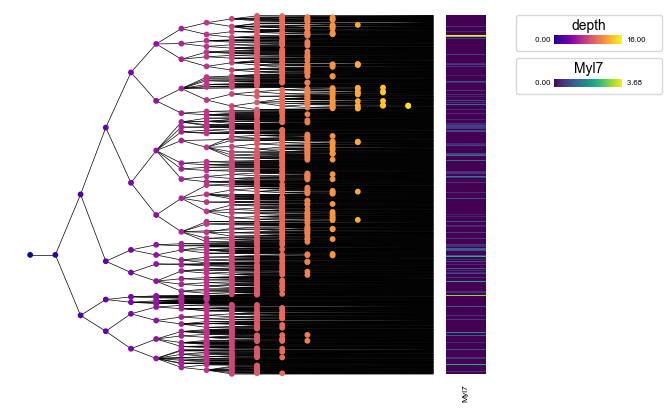

In [82]:

py.pp.add_depth(adata)
py.pl.branches(adata, extend_branches=True, tree="E8.0-R1-C2", angled_branches=True)
py.pl.nodes(adata, color='depth', cmap="plasma")
py.pl.annotation(adata, keys='Myl7', cmap='viridis', width=.1)

#### Running Katie's Plotting Code

In [42]:
from Moslin.utility import add_gene_expression_to_tree, add_obs_to_tree, add_node_attrs_to_edges, flag_mixed_nodes

In [48]:
tdata_rep1 = tdatas[2]
tdata_rep1

TreeData object with n_obs × n_vars = 4648 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'depth'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'leiden_0.25', 'leiden_0.25_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'leiden_names', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters'
    varm: 'PCs'
    layers: 'Norm_count', 'Raw_count'
    obsp: 'connectivities', 'distances'
    obst: 'E7.5-R2-C6', 'E7.5-R2-C3', 'E7.5-R2-C1', 'E7.5-R3-C1', 'E7.5-R2-C4', 'E7.5-R2-C2', 'E7.5-R3-C2', 'E7.5-R1-C2', 'E7.5-R2-C5', 'E7.5-R1-C1', 'E7.5-R3-C3'

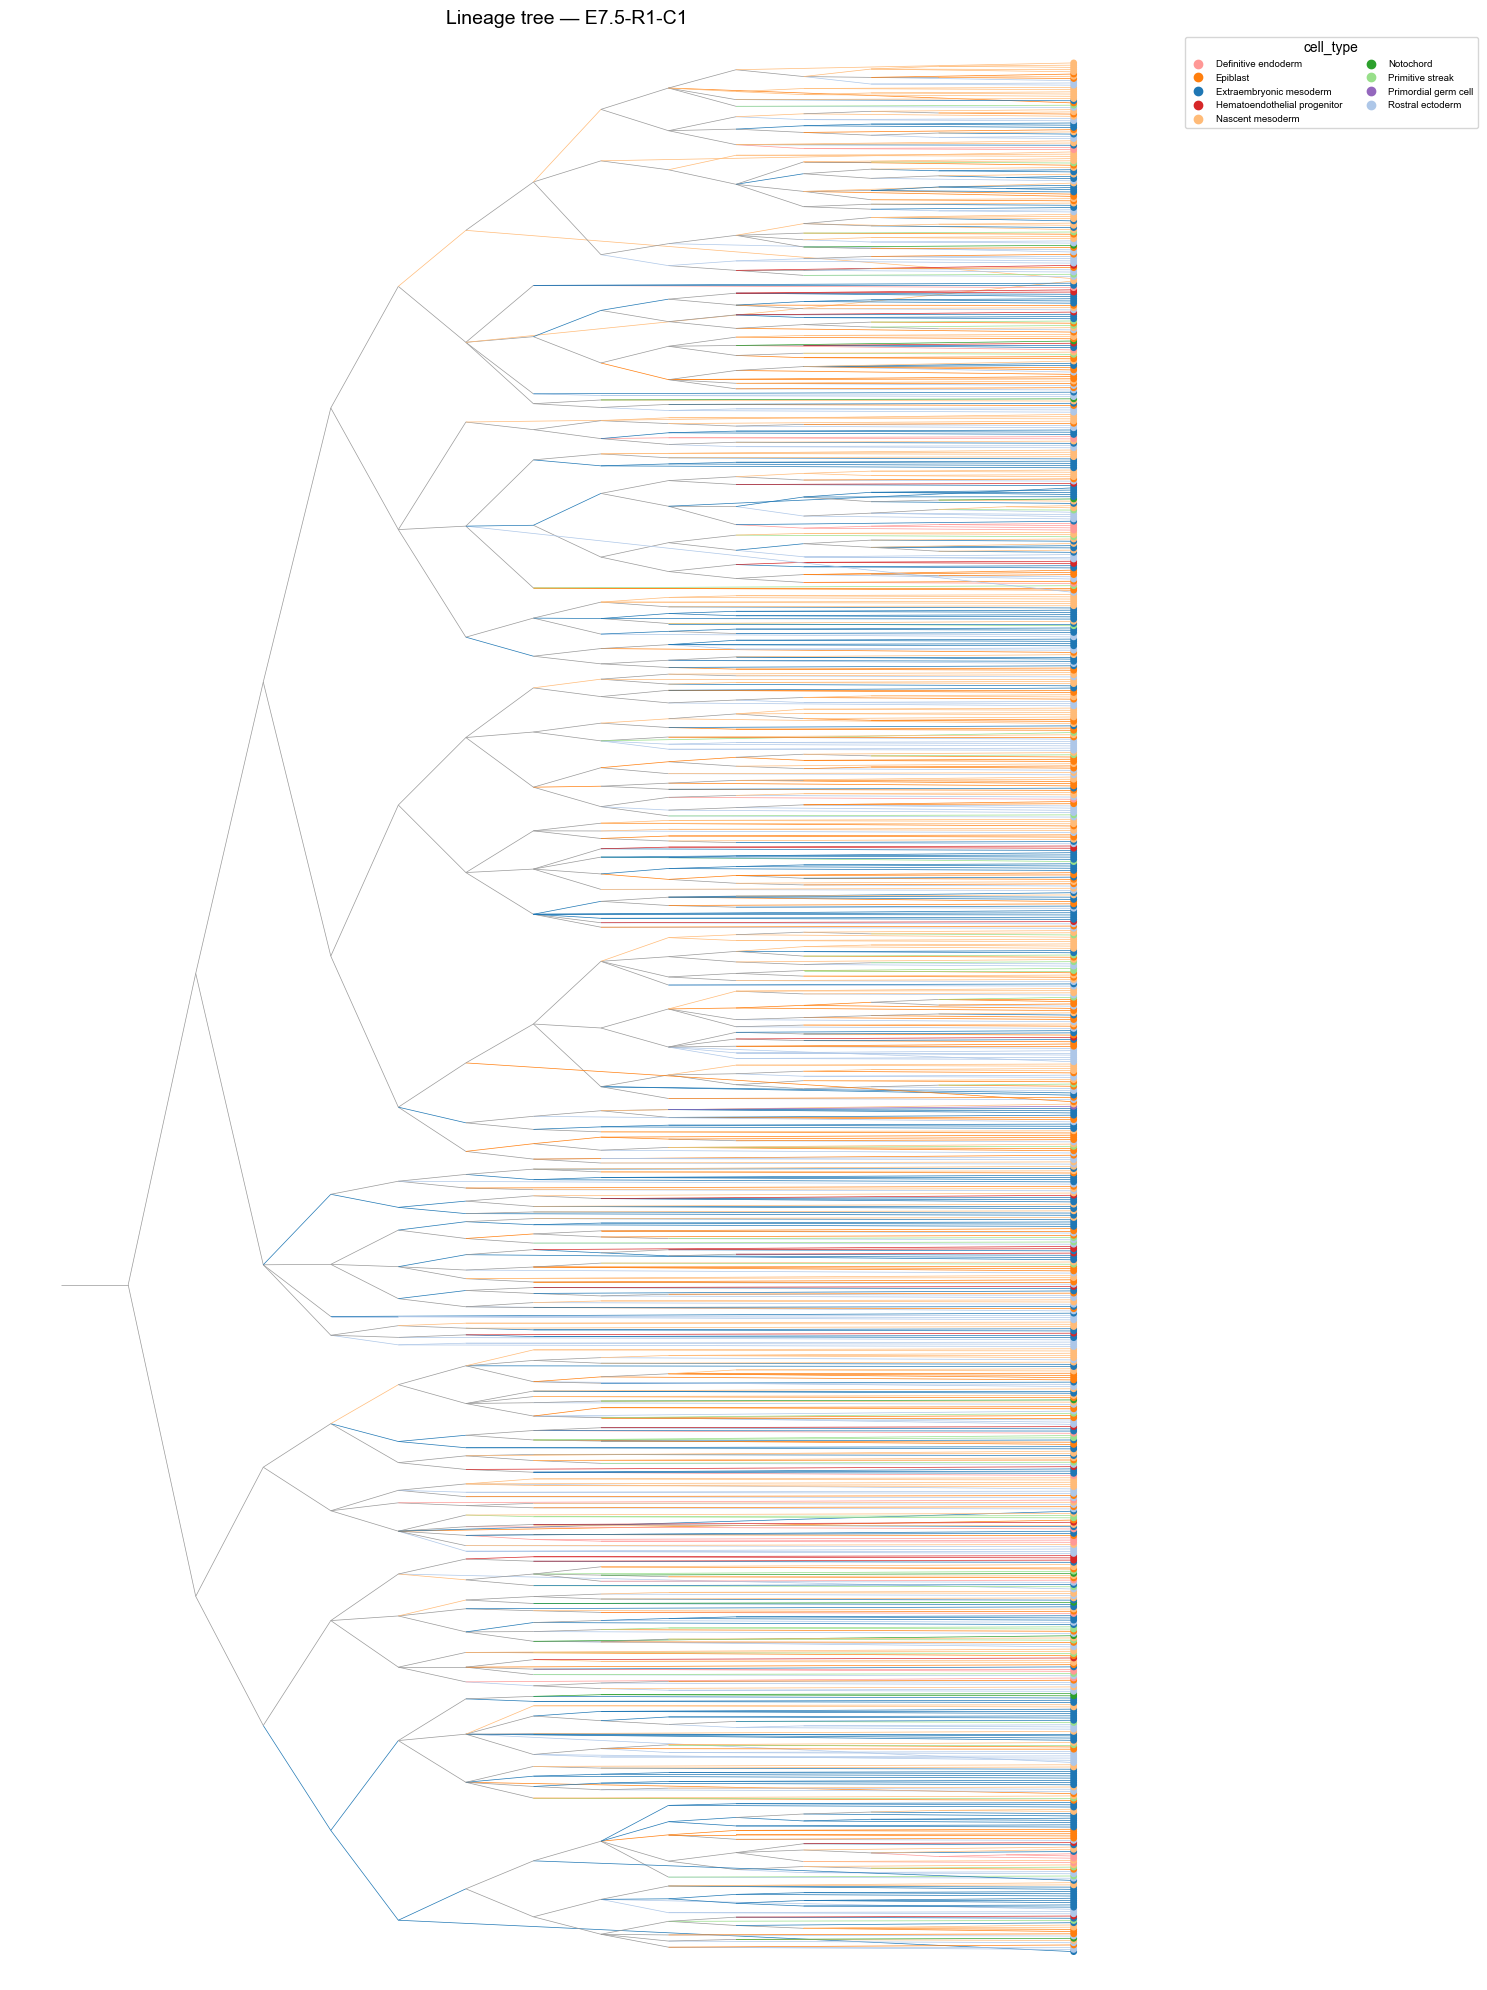

In [53]:
clone_key = "E7.5-R1-C1"
clone_tdata = tdata_rep1[tdata_rep1.obs["tree"] == clone_key].copy()
add_obs_to_tree(clone_tdata, keys=["cell_type", "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys="cell_type", tree=clone_key, method="mode")
# override mixed internal nodes
flag_mixed_nodes(clone_tdata, clone_key, cell_type_key="cell_type")
# propagate to edges
add_node_attrs_to_edges(clone_tdata, keys=["cell_type", "germ_layer"])



# build palette: take your existing cell type colors and add mixed
import matplotlib.pyplot as plt

# get unique cell types present in this clone
cell_types = clone_tdata.obs["cell_type"].unique().tolist()
palette = dict(zip(cell_types, plt.cm.tab20.colors[:len(cell_types)]))
palette["mixed"] = (0.6, 0.6, 0.6, 1.0)  # grey for mixed nodes

fig, ax = plt.subplots(figsize=(15, 20))
py.pl.branches(
    clone_tdata,
    depth_key="depth",
    color="cell_type",
    palette=palette,
    extend_branches=True,
    angled_branches=True,
    tree=clone_key,
    legend=False,
    ax=ax,
)
py.pl.nodes(
    clone_tdata,
    color="cell_type",
    palette=palette,
    nodes="leaves",
    size=15,
    legend=True,
    legend_kwargs={"ncols": 2, "bbox_to_anchor": (1.05, 1), "loc": "upper left"},
    tree=clone_key,
    ax=ax,
)
ax.set_title(f"Lineage tree — {clone_key}", fontsize=14)
plt.tight_layout()
#plt.show()
plt.savefig(output_path_plot+"output.svg")

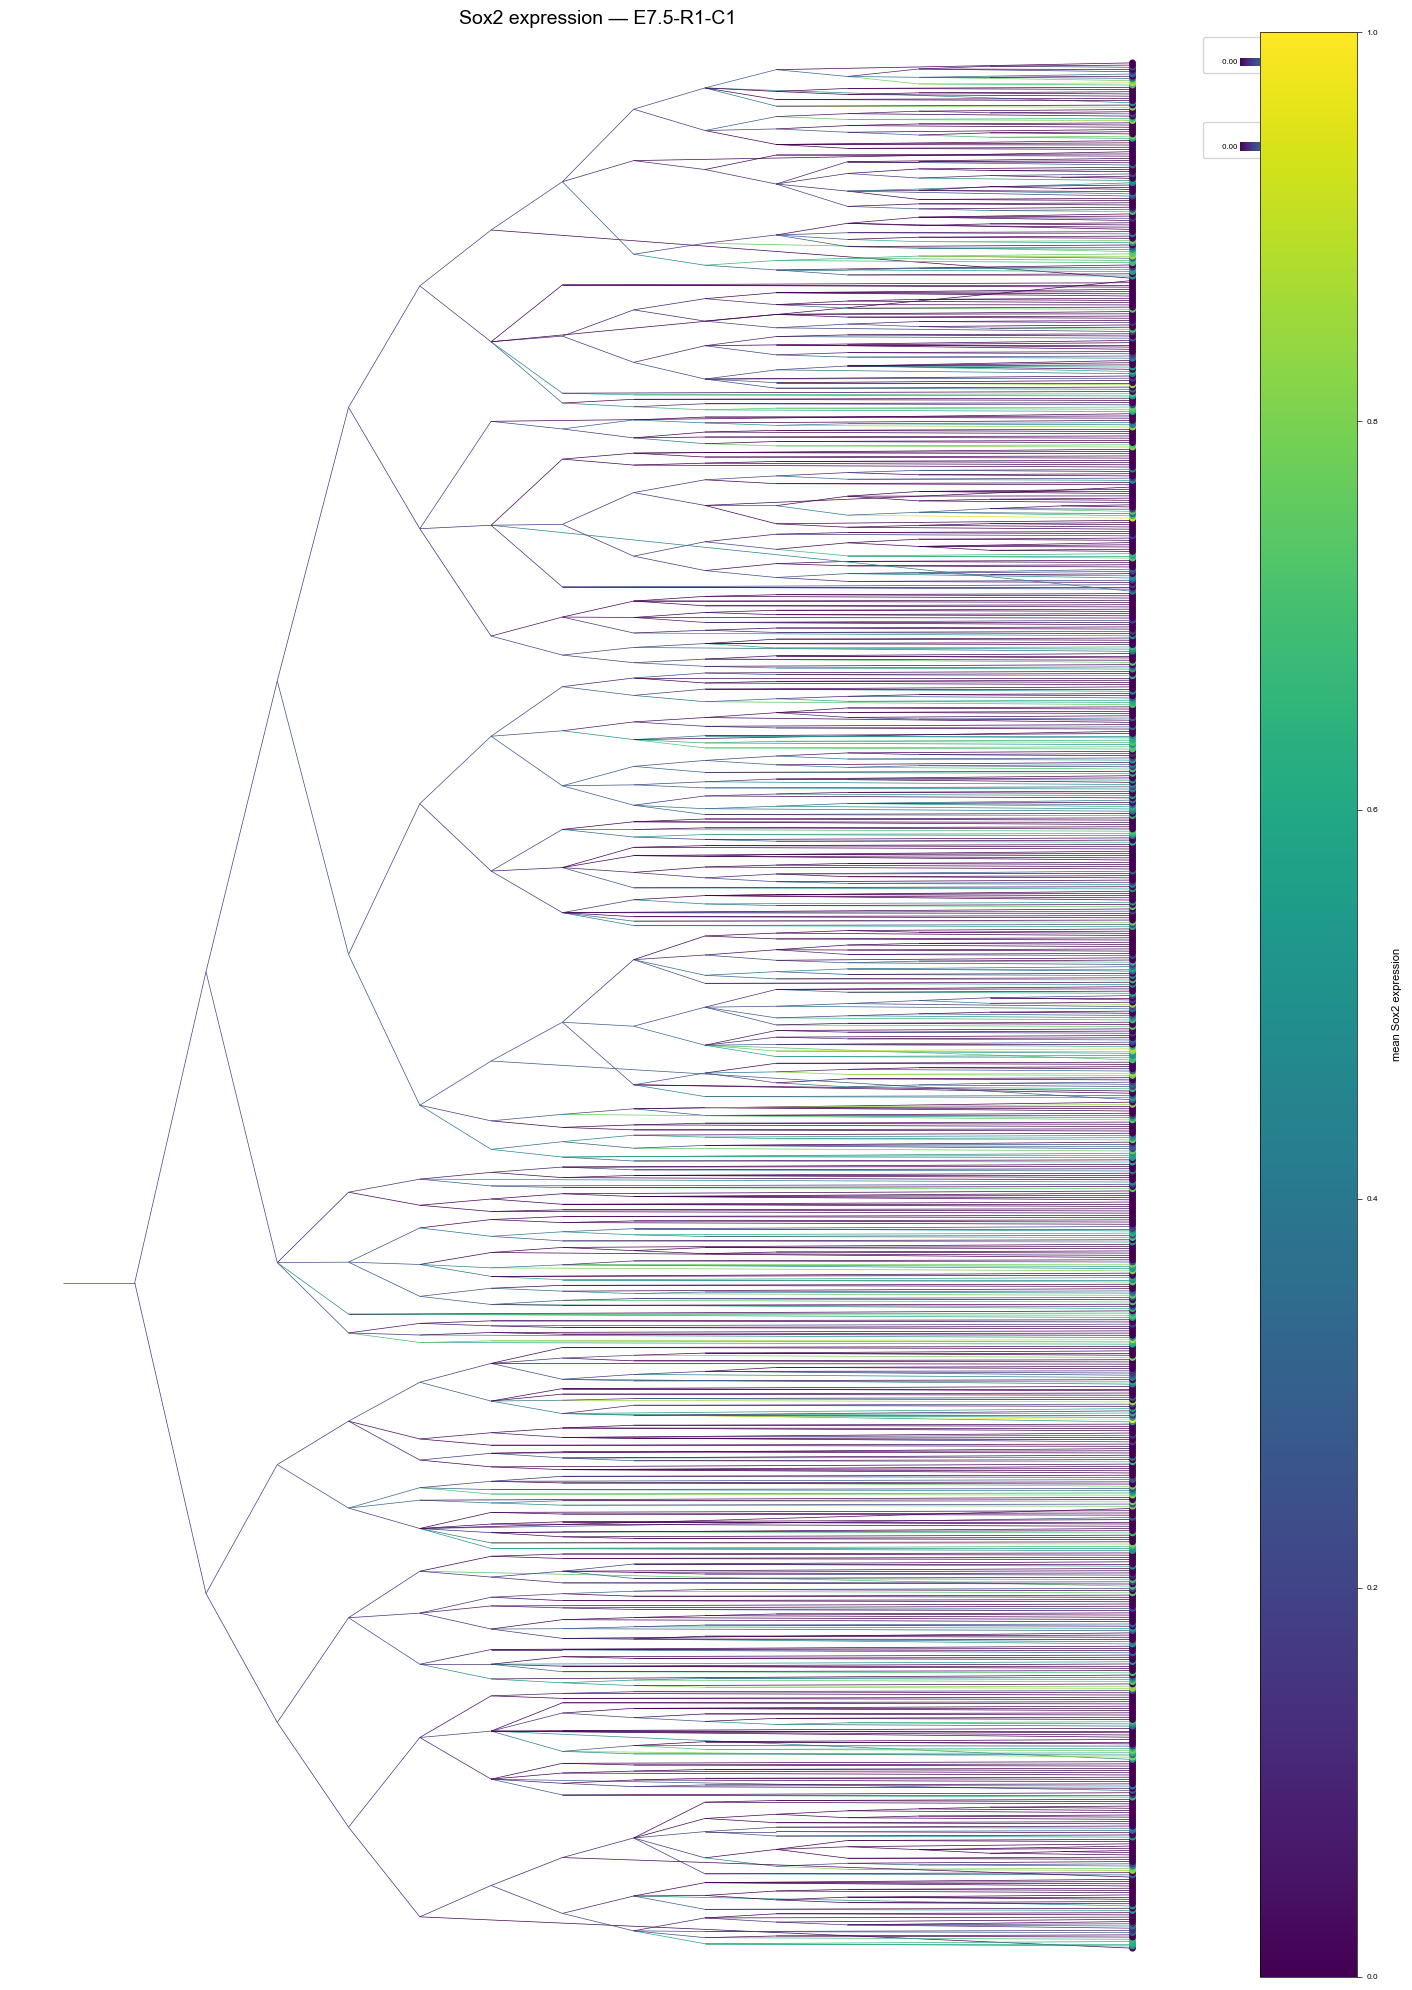

In [50]:
def add_gene_expression_to_tree(tdata, tree_key, gene, layer=None):
    """
    For each leaf node, add mean expression of gene as a node attribute.
    For internal nodes, use the mean across all descendant leaves.

    Parameters
    ----------
    tdata : TreeData
    tree_key : str
    gene : str, must be in tdata.var_names
    layer : str or None, if None uses tdata.X
    """
    tree = tdata.obst[tree_key]

    # get expression vector for all cells
    gene_idx = tdata.var_names.get_loc(gene)
    if layer is not None:
        expr = np.array(tdata.layers[layer][:, gene_idx]).flatten()
    else:
        import scipy.sparse as sp
        X = tdata.X
        expr = np.array(X[:, gene_idx].todense()).flatten() if sp.issparse(X) else X[:, gene_idx]

    # map barcode -> expression value
    barcode_to_expr = dict(zip(tdata.obs.index, expr))

    # for each node, compute mean expression across all descendant leaves
    for node in reversed(list(nx.topological_sort(tree))):
        if tree.out_degree(node) == 0:
            # leaf: look up directly
            val = barcode_to_expr.get(node, np.nan)
        else:
            # internal: mean over all descendant leaves
            desc_leaves = [
                n for n in nx.descendants(tree, node)
                if tree.out_degree(n) == 0
            ]
            vals = [barcode_to_expr[l] for l in desc_leaves if l in barcode_to_expr]
            val = np.mean(vals) if vals else np.nan
        tree.nodes[node][gene] = val
        
gene = "Sox2"  # replace with your gene of interest
add_gene_expression_to_tree(clone_tdata, clone_key, gene=gene)
add_node_attrs_to_edges(clone_tdata, keys=[gene]) 

# plot:
fig, ax = plt.subplots(figsize=(15, 20))

py.pl.branches(
    clone_tdata,
    depth_key="depth",
    color=gene,              # continuous attribute name
    cmap="viridis",          # or "RdBu_r", "magma", etc.
    extend_branches=True,
    angled_branches=True,
    tree=clone_key,
    ax=ax,
)
py.pl.nodes(
    clone_tdata,
    color=gene,
    nodes="leaves",
    cmap="viridis",
    size=15,
    tree=clone_key,
    ax=ax,
)

ax.set_title(f"{gene} expression — {clone_key}", fontsize=14)
plt.colorbar(ax.collections[0], ax=ax, label=f"mean {gene} expression")
plt.tight_layout()
plt.show()